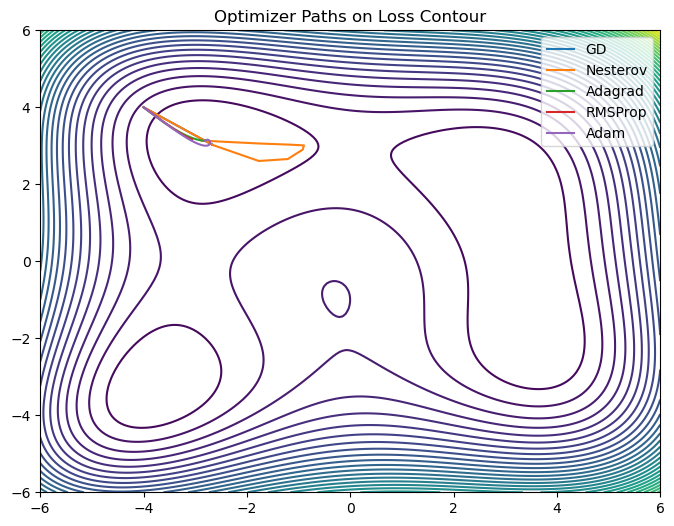

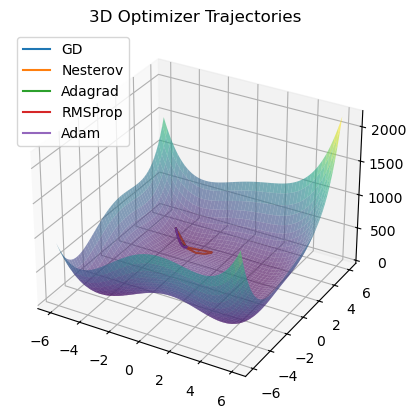

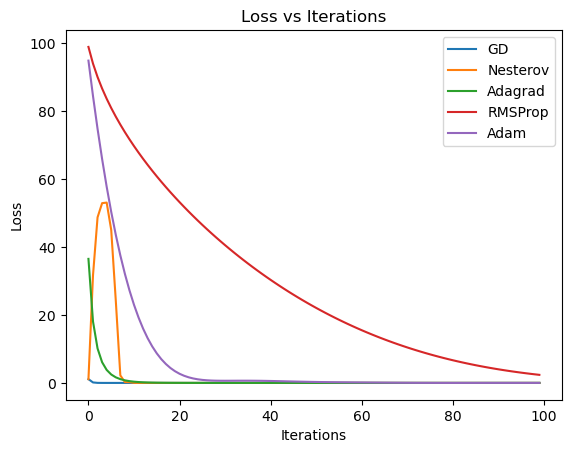

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Himmelblau function
def loss_func(w):
    a, b = w
    return (a**2 + b - 11)**2 + (a + b**2 - 7)**2

# Gradient of the function
def grad_loss(w):
    a, b = w
    da = 4*a*(a**2 + b - 11) + 2*(a + b**2 - 7)
    db = 2*(a**2 + b - 11) + 4*b*(a + b**2 - 7)
    return np.array([da, db])

# Gradient Descent
def gradient_descent(start, lr=0.01, steps=100):
    w = start.copy()
    track = [w.copy()]
    losses = []
    for i in range(steps):
        w = w - lr * grad_loss(w)
        track.append(w.copy())
        losses.append(loss_func(w))
    return np.array(track), losses

# Nesterov Optimizer
def nesterov_opt(start, lr=0.01, gamma=0.9, steps=100):
    w = start.copy()
    velocity = np.zeros_like(w)
    track = [w.copy()]
    losses = []
    for i in range(steps):
        look = w - gamma * velocity
        g = grad_loss(look)
        velocity = gamma * velocity + lr * g
        w = w - velocity
        track.append(w.copy())
        losses.append(loss_func(w))
    return np.array(track), losses

# Adagrad
def adagrad_opt(start, lr=0.4, steps=100):
    w = start.copy()
    G = np.zeros_like(w)
    eps = 1e-8
    track = [w.copy()]
    losses = []
    for i in range(steps):
        g = grad_loss(w)
        G += g**2
        w = w - lr * g / (np.sqrt(G) + eps)
        track.append(w.copy())
        losses.append(loss_func(w))
    return np.array(track), losses

# RMSProp
def rmsprop_opt(start, lr=0.01, beta=0.9, steps=100):
    w = start.copy()
    avg = np.zeros_like(w)
    eps = 1e-8
    track = [w.copy()]
    losses = []
    for i in range(steps):
        g = grad_loss(w)
        avg = beta * avg + (1 - beta) * (g**2)
        w = w - lr * g / (np.sqrt(avg) + eps)
        track.append(w.copy())
        losses.append(loss_func(w))
    return np.array(track), losses

# Adam Optimizer
def adam_opt(start, lr=0.05, steps=100):
    w = start.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    b1, b2 = 0.9, 0.999
    eps = 1e-8
    track = [w.copy()]
    losses = []
    for t in range(1, steps + 1):
        g = grad_loss(w)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * (g**2)
        m_hat = m / (1 - b1**t)
        v_hat = v / (1 - b2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        track.append(w.copy())
        losses.append(loss_func(w))
    return np.array(track), losses


start_point = np.array([-4.0, 4.0])

optim_dict = {
    "GD": gradient_descent,
    "Nesterov": nesterov_opt,
    "Adagrad": adagrad_opt,
    "RMSProp": rmsprop_opt,
    "Adam": adam_opt
}

paths = {}
loss_values = {}

for key, fn in optim_dict.items():
    paths[key], loss_values[key] = fn(start_point)

x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x, y)
Z = loss_func([X, Y])

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, 40)

for k, p in paths.items():
    plt.plot(p[:,0], p[:,1], label=k)

plt.legend()
plt.title("Optimizer Paths on Loss Contour")
plt.show()

# 3D Surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.6)

for k, p in paths.items():
    z_vals = [loss_func(w) for w in p]
    ax.plot(p[:,0], p[:,1], z_vals, label=k)

ax.set_title("3D Optimizer Trajectories")
plt.legend()
plt.show()

# Loss curves
plt.figure()

for k, l in loss_values.items():
    plt.plot(l, label=k)

plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.show()

# MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

mask = (y_train == 0) | (y_train == 1)
x = x_train[mask]
y = y_train[mask]

x = x.reshape(len(x), -1)

f1 = x[:, :392].mean(axis=1)
f2 = x[:, 392:].mean(axis=1)

X = np.vstack((f1, f2)).T
X = StandardScaler().fit_transform(X)

y = y.astype(np.float32)

def sigmoid_fn(z):
    return 1 / (1 + np.exp(-z))

def logistic_loss(w):
    p = sigmoid_fn(X.dot(w))
    return -np.mean(y*np.log(p+1e-8) + (1-y)*np.log(1-p+1e-8))

def logistic_grad(w):
    p = sigmoid_fn(X.dot(w))
    return X.T.dot(p - y) / len(y)

def train_adam_lr(steps=200, lr=0.05):
    w = np.zeros(2)
    m = np.zeros(2)
    v = np.zeros(2)
    b1, b2 = 0.9, 0.999
    eps = 1e-8
    track = [w.copy()]
    losses = []

    for t in range(1, steps+1):
        g = logistic_grad(w)
        m = b1*m + (1-b1)*g
        v = b2*v + (1-b2)*(g**2)

        m_hat = m/(1-b1**t)
        v_hat = v/(1-b2**t)

        w = w - lr*m_hat/(np.sqrt(v_hat)+eps)

        track.append(w.copy())
        losses.append(logistic_loss(w))

    return np.array(track), losses


path_lr, loss_lr_vals = train_adam_lr()